# Market Regime Detection — Modeling

This notebook trains supervised models to predict the market regime **20 trading days ahead**.

In [1]:
import sys
from pathlib import Path

repo_root = Path().resolve().parent  # <-- this is market-regime-detection
sys.path.insert(0, str(repo_root))

print("Added repo root:", repo_root)
print("sys.path[0]:", sys.path[0])

Added repo root: C:\Users\llr\market-regime-detection
sys.path[0]: C:\Users\llr\market-regime-detection


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [3]:
from src.config import CFG
from src.data_ingest import load_ohlcv
from src.features import make_features
from src.labels import label_regimes, make_target, REGIME_ORDER

df = load_ohlcv(start=CFG.start)
feat = make_features(df, vol_window=CFG.vol_window, trend_window=CFG.trend_window)
regime = label_regimes(feat, vol_quantile=CFG.vol_quantile)
target = make_target(regime, horizon=CFG.horizon)

ds = feat.join(regime).join(target).dropna()
ds.head(), ds.shape

(               Open     High      Low    Close    Volume  log_close    ret_1d  \
 Date                                                                            
 2005-05-23  91.9843  92.6083  91.9651  92.4159  66482810   4.526299  0.005491   
 2005-05-24  92.1567  92.4630  91.9749  92.2142  66100846   4.524114 -0.002185   
 2005-05-25  92.1010  92.4906  91.6895  92.1394  62840231   4.523303 -0.000811   
 2005-05-26  92.4256  92.7385  92.2973  92.6160  56457030   4.528462  0.005159   
 2005-05-27  92.6248  92.7771  92.4351  92.7771  31938170   4.530200  0.001738   
 
              vol_20d  trend_60d    mom_5d   mom_20d  hl_range  co_return  \
 Date                                                                       
 2005-05-23  0.007601  -0.013744  0.025159  0.029265  0.006960   0.004692   
 2005-05-24  0.007194  -0.009070  0.016462  0.036801  0.005293   0.000624   
 2005-05-25  0.007199  -0.015072  0.005301  0.032069  0.008694   0.000417   
 2005-05-26  0.006404  -0.009421  0.006

In [4]:
feature_cols = ["ret_1d","vol_20d","trend_60d","mom_5d","mom_20d","hl_range","co_return","volchg_5d"]

X = ds[feature_cols]
y = ds["target_regime"]

y.value_counts()

target_regime
bull_calm        3243
bear_volatile     977
bull_volatile     592
bear_calm         411
Name: count, dtype: int64

In [5]:
tscv = TimeSeriesSplit(n_splits=5)

baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

scores = []
for fold, (tr, te) in enumerate(tscv.split(X), start=1):
    baseline.fit(X.iloc[tr], y.iloc[tr])
    pred = baseline.predict(X.iloc[te])
    acc = accuracy_score(y.iloc[te], pred)
    scores.append(acc)
    print(f"Fold {fold} accuracy: {acc:.3f}")

print(f"Mean CV accuracy: {np.mean(scores):.3f} ± {np.std(scores):.3f}")

Fold 1 accuracy: 0.787
Fold 2 accuracy: 0.824
Fold 3 accuracy: 0.869
Fold 4 accuracy: 0.831
Fold 5 accuracy: 0.897
Mean CV accuracy: 0.842 ± 0.038


In [14]:
rf = RandomForestClassifier(
    n_estimators=800,
    random_state=CFG.random_state,
    class_weight="balanced_subsample",
    n_jobs=-1
)

rf_pipe = Pipeline([
    ("clf", rf)
])

scores = []
for fold, (tr, te) in enumerate(tscv.split(X), start=1):
    rf_pipe.fit(X.iloc[tr], y.iloc[tr])
    pred = rf_pipe.predict(X.iloc[te])
    acc = accuracy_score(y.iloc[te], pred)
    scores.append(acc)
    print(f"Fold {fold} accuracy: {acc:.3f}")

print(f"Mean CV accuracy: {np.mean(scores):.3f} ± {np.std(scores):.3f}")

Fold 1 accuracy: 0.695
Fold 2 accuracy: 0.807
Fold 3 accuracy: 0.871
Fold 4 accuracy: 0.740
Fold 5 accuracy: 0.905
Fold 6 accuracy: 0.843
Fold 7 accuracy: 0.803
Fold 8 accuracy: 0.929
Mean CV accuracy: 0.824 ± 0.075


In [7]:
# extract feature importance from rf
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": importance
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
2,trend_60d,0.294557
1,vol_20d,0.273815
4,mom_20d,0.103629
5,hl_range,0.100394
3,mom_5d,0.068225
0,ret_1d,0.055139
7,volchg_5d,0.052547
6,co_return,0.051694


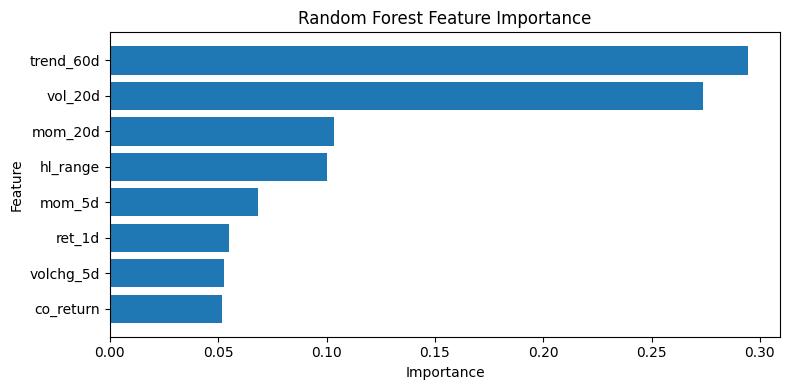

In [8]:
plt.figure(figsize=(8,4))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
RESULTS_DIR = Path("../reports/figures")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(RESULTS_DIR / "feature_importance_random_forest.png", dpi=200)
plt.show()

Holdout accuracy: 0.876555023923445
               precision    recall  f1-score   support

    bear_calm       0.75      0.42      0.54        72
bear_volatile       0.83      0.91      0.87       227
    bull_calm       0.91      0.97      0.94       640
bull_volatile       0.76      0.54      0.63       106

     accuracy                           0.88      1045
    macro avg       0.81      0.71      0.74      1045
 weighted avg       0.87      0.88      0.87      1045



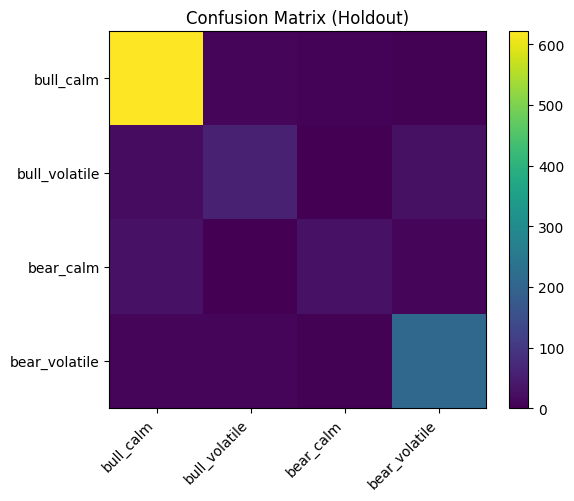

In [9]:
split = int(len(ds) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

rf_pipe.fit(X_train, y_train)
pred = rf_pipe.predict(X_test)

print("Holdout accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred, labels=REGIME_ORDER)
plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.xticks(range(len(REGIME_ORDER)), REGIME_ORDER, rotation=45, ha="right")
plt.yticks(range(len(REGIME_ORDER)), REGIME_ORDER)
plt.title("Confusion Matrix (Holdout)")
plt.colorbar()
plt.tight_layout()
plt.show()

In [10]:
import pandas as pd
from pathlib import Path

csv_path = repo_root /"reports"/"horizon_model_results.csv"

results = pd.read_csv(csv_path)
results

,horizon,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std
0,5,hgb,0.817672,0.075438,0.625313,0.059119,0.624882,0.085093
1,5,rf,0.825647,0.078649,0.628467,0.058292,0.632570,0.087806
2,10,hgb,0.761226,0.076583,0.523545,0.057448,0.520595,0.072760
3,10,rf,0.775691,0.079172,0.513332,0.062245,0.511300,0.080758
4,20,hgb,0.650087,0.131379,0.385358,0.045627,0.372253,0.067735
5,20,rf,0.685121,0.136717,0.392716,0.042876,0.377074,0.062337
6,60,hgb,0.503049,0.123846,0.252255,0.036378,0.243076,0.047910
7,60,rf,0.567509,0.155086,0.266810,0.038955,0.237951,0.046057


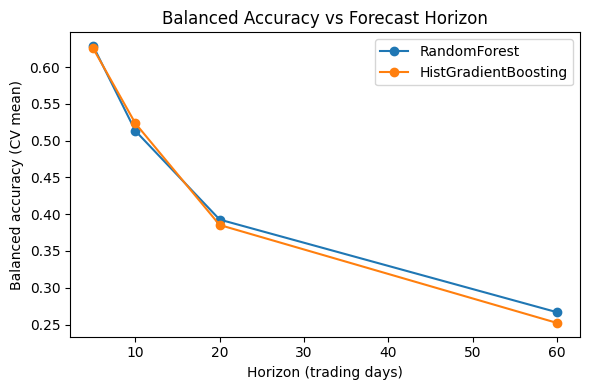

In [11]:
import matplotlib.pyplot as plt

pivot = results.pivot(index="horizon", columns="model", values="balanced_accuracy_mean")

plt.figure(figsize=(6,4))
plt.plot(pivot.index, pivot["rf"], marker="o", label="RandomForest")
plt.plot(pivot.index, pivot["hgb"], marker="o", label="HistGradientBoosting")
plt.title("Balanced Accuracy vs Forecast Horizon")
plt.xlabel("Horizon (trading days)")
plt.ylabel("Balanced accuracy (CV mean)")
plt.legend()
plt.tight_layout()
plt.show()

               count      mean       std  sharpe_like
pred_regime                                          
bear_calm        196  0.002787  0.027138     0.102683
bull_volatile    312  0.002580  0.024896     0.103643
bear_volatile   1033  0.002001  0.040983     0.048814
bull_calm       3099  0.001746  0.017103     0.102085


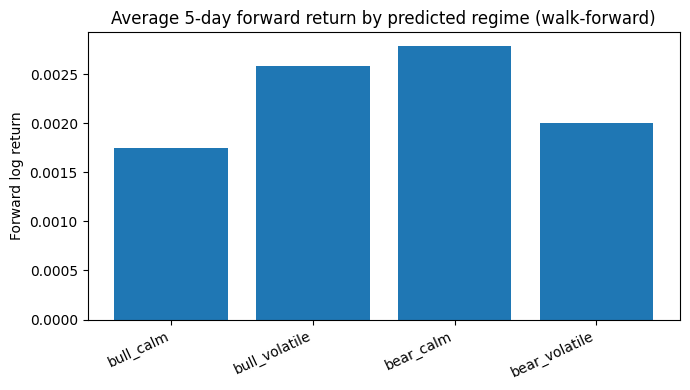

In [15]:
from src.model import make_model

tscv = TimeSeriesSplit(n_splits=8)
preds = pd.Series(index=X.index, dtype="object")

for tr, te in tscv.split(X):
    m = make_model("rf")
    m.fit(X.iloc[tr], y.iloc[tr])
    preds.iloc[te] = m.predict(X.iloc[te])

# compute forward return over horizon being predicted
h = CFG.horizon
ds2 = ds.copy()
ds2["pred_regime"] = preds
ds2["fwd_return"] = np.log(df["Close"]).diff(h).shift(-h)
ds2 = ds2.dropna(subset=["pred_regime","fwd_return"])

# forward returns by predicted market regime
summary = ds2.groupby("pred_regime")["fwd_return"].agg(["count","mean","std"]).sort_values("mean",ascending=False)
summary["sharpe_like"] = summary["mean"] / summary["std"]
print(summary)


means = ds2.groupby("pred_regime")["fwd_return"].mean().reindex(REGIME_ORDER)
plt.figure(figsize=(7,4))
plt.bar(means.index, means.values)
plt.title(f"Average {CFG.horizon}-day forward return by predicted regime (walk-forward)")
plt.xticks(rotation=25, ha="right")
plt.ylabel("Forward log return")
plt.tight_layout()
plt.show()

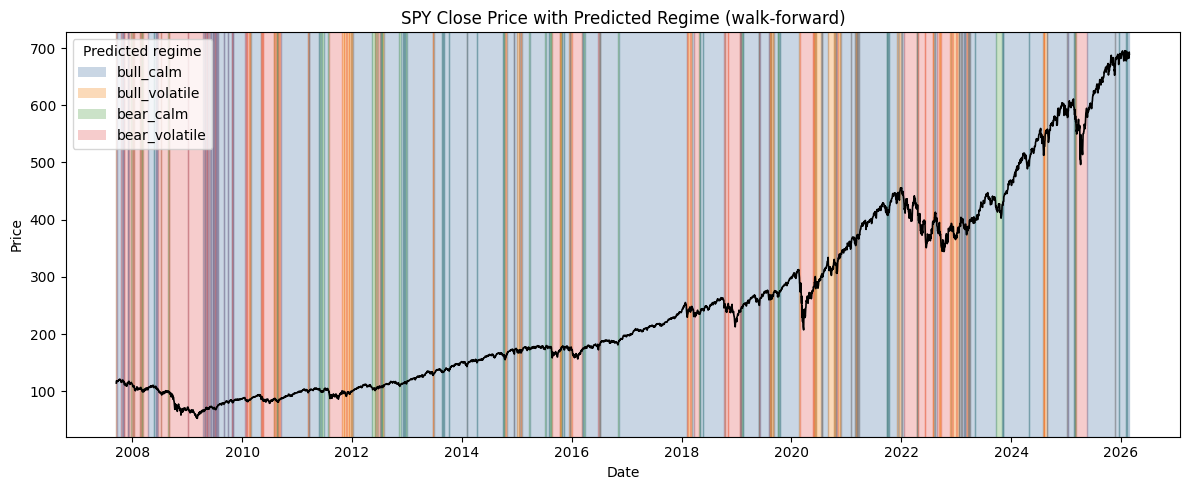

In [13]:
from matplotlib.patches import Patch

# plotting dataframe
plot_df = pd.DataFrame(index=ds2.index)
plot_df["Close"] = df["Close"].reindex(plot_df.index)
plot_df["pred_regime"] = ds2["pred_regime"].astype(str)

plot_df = plot_df.dropna(subset=["Close", "pred_regime"]).copy()

# Fixed colors per regime (readable + consistent)
color_map = {
    "bull_calm": "#4C78A8",
    "bull_volatile": "#F58518",
    "bear_calm": "#54A24B",
    "bear_volatile": "#E45756",
}

# Plot price
plt.figure(figsize=(12, 5))
plt.plot(plot_df.index, plot_df["Close"], linewidth=1.2, color="black")
plt.title("SPY Close Price with Predicted Regime (walk-forward)")
plt.xlabel("Date")
plt.ylabel("Price")

# Shade background by contiguous regime blocks
regimes = plot_df["pred_regime"].to_numpy()
dates = plot_df.index.to_numpy()

start = 0
for i in range(1, len(regimes)):
    if regimes[i] != regimes[i-1]:
        r = regimes[i-1]
        plt.axvspan(dates[start], dates[i], alpha=0.3, color=color_map.get(r, "#999999"))
        start = i

# last block
r = regimes[-1]
plt.axvspan(dates[start], dates[-1], alpha=0.3, color=color_map.get(r, "#999999"))

handles = [Patch(facecolor=color_map[r], alpha=0.3, label=r) for r in REGIME_ORDER]
plt.legend(handles=handles, title="Predicted regime", loc="upper left")

# Save and show
RESULTS_DIR = Path("../reports/figures")   # go up from notebooks → repo root
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

plt_save_path = RESULTS_DIR / "price_with_predicted_regime.png"

plt.tight_layout()
plt.savefig(plt_save_path, dpi=200)
plt.show()